In [13]:
import pandas as pd
import numpy as np

# Direct Windows absolute path (paste your exact path)
CSV_PATH = r"C:\Users\prash\Downloads\Customer_data - customer_data.csv"


In [14]:
df = pd.read_csv(CSV_PATH, encoding="utf-8")
print("Shape:", df.shape)
df.head(3)


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [15]:
df.columns = [c.strip() for c in df.columns]
assert "Churn" in df.columns, "Target 'Churn' not found"

df["Churn"] = df["Churn"].astype(str).str.strip().str.lower().map({"yes":1, "no":0})
assert df["Churn"].isin([0,1]).all(), "Churn must be Yes/No only"

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.strip()

print("Churn positive rate:", round(df["Churn"].mean(), 3))
df.isna().sum().sort_values(ascending=False).head(10)


Churn positive rate: 0.265


TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

y = df["Churn"].values
drop_cols = ["Churn"] + (["customerID"] if "customerID" in df.columns else [])
X = df.drop(columns=drop_cols)

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print(f"Train {X_train.shape} | Test {X_test.shape} | Num {len(num_cols)} | Cat {len(cat_cols)}")


Train (5634, 19) | Test (1409, 19) | Num 4 | Cat 15


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

scoring = {"accuracy":"accuracy","precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_eval(model, name):
    pipe = Pipeline([("pre", pre), ("model", model)])
    out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model":name}
    for k,v in out.items():
        if k.startswith("test_"):
            row[k.replace("test_","").upper()] = round(v.mean(), 3)
    return row

rows = []
rows.append(cv_eval(LogisticRegression(max_iter=10000, class_weight="balanced", solver="liblinear", random_state=42), "LogReg(bal)"))
rows.append(cv_eval(RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, class_weight="balanced_subsample", random_state=42), "RF(base)"))
rows.append(cv_eval(HistGradientBoostingClassifier(learning_rate=0.05, max_depth=6, max_iter=600, random_state=42), "HGB(base)"))

cv_results = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
cv_results


,model,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
0,LogReg(bal),0.749,0.517,0.801,0.629,0.846
1,RF(base),0.786,0.589,0.643,0.614,0.838
2,HGB(base),0.790,0.628,0.512,0.563,0.827


In [18]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression
log_pipe = Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=12000, class_weight="balanced", solver="liblinear", random_state=42))])
log_grid = {"model__C":[0.1, 0.3, 1.0, 3.0]}
log_gs = GridSearchCV(log_pipe, log_grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)

# RandomForest
rf_pipe = Pipeline([("pre", pre), ("model", RandomForestClassifier(n_jobs=-1, class_weight="balanced_subsample", random_state=42))])
rf_grid = {"model__n_estimators":[400,700], "model__min_samples_leaf":[1,2], "model__max_depth":[None,20]}
rf_gs = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)

# HistGB
hgb_pipe = Pipeline([("pre", pre), ("model", HistGradientBoostingClassifier(random_state=42))])
hgb_grid = {"model__learning_rate":[0.03,0.05], "model__max_depth":[6,8], "model__max_iter":[500,800]}
hgb_gs = GridSearchCV(hgb_pipe, hgb_grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)

best_est, best_name, best_auc = None, None, -1
for name, gs in [("LogReg", log_gs), ("RF", rf_gs), ("HGB", hgb_gs)]:
    if gs.best_score_ > best_auc:
        best_auc, best_est, best_name = gs.best_score_, gs.best_estimator_, name
{"BEST": best_name, "CV_AUC": round(best_auc, 3)}


{'BEST': 'LogReg', 'CV_AUC': np.float64(0.846)}

{'TEST_ACC': 0.74, 'TEST_PREC': 0.506, 'TEST_REC': 0.783, 'TEST_F1': 0.615, 'TEST_AUC': np.float64(0.841)}
Confusion Matrix:
 [[749 286]
 [ 81 293]]
              precision    recall  f1-score   support

           0      0.902     0.724     0.803      1035
           1      0.506     0.783     0.615       374

    accuracy                          0.740      1409
   macro avg      0.704     0.754     0.709      1409
weighted avg      0.797     0.740     0.753      1409



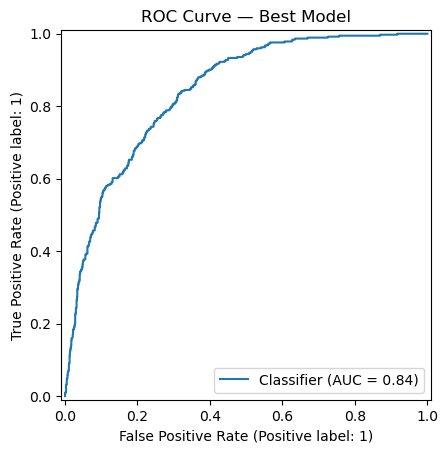

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

best_est.fit(X_train, y_train)
y_pred = best_est.predict(X_test)

y_score = best_est.predict_proba(X_test)[:,1] if hasattr(best_est.named_steps["model"], "predict_proba") else best_est.decision_function(X_test)

acc = round(accuracy_score(y_test, y_pred), 3)
prec = round(precision_score(y_test, y_pred), 3)
rec = round(recall_score(y_test, y_pred), 3)
f1 = round(f1_score(y_test, y_pred), 3)
auc = round(roc_auc_score(y_test, y_score), 3)
print({"TEST_ACC": acc, "TEST_PREC": prec, "TEST_REC": rec, "TEST_F1": f1, "TEST_AUC": auc})

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

RocCurveDisplay.from_predictions(y_test, y_score)
plt.title("ROC Curve — Best Model")
plt.show()


In [21]:
# Permutation Importance — robust, error-safe cell

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# 0) Ensure the pipeline is fitted
_ = best_est.fit(X_train, y_train)

# 1) Compute permutation importance on the full pipeline
perm = permutation_importance(
    best_est, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1
)

# 2) Extract feature names from ColumnTransformer in the fitted pipeline
pre = best_est.named_steps["pre"]

def get_feature_names_from_pre(pre, num_cols_hint=None, cat_cols_hint=None):
    # Try modern API
    try:
        names = pre.get_feature_names_out().tolist()
        return names
    except Exception:
        pass
    # Fallback manual extraction with prefixes for clarity
    names = []
    # Gather transformer tuples: (name, transformer, cols)
    transformers = [(name, trans, cols) for name, trans, cols in pre.transformers_ if name != "remainder"]
    for name, trans, cols in transformers:
        if name == "num":
            # After SimpleImputer+StandardScaler, numeric count equals len(cols)
            names += [f"num__{c}" for c in cols]
        elif name == "cat":
            # OneHotEncoder expanded names
            ohe = trans.named_steps.get("ohe", None)
            if ohe is None:
                continue
            base_cols = cols if cat_cols_hint is None else cat_cols_hint
            if hasattr(ohe, "get_feature_names_out"):
                cat_names = ohe.get_feature_names_out(base_cols).tolist()
            else:
                cat_names = ohe.get_feature_names(base_cols).tolist()
            names += [f"cat__{c}" for c in cat_names]
        else:
            # Any other transformer — attempt generic handling
            try:
                if hasattr(trans, "get_feature_names_out"):
                    names += trans.get_feature_names_out(cols).tolist()
                else:
                    names += [f"{name}__{c}" for c in cols]
            except Exception:
                names += [f"{name}__{c}" for c in cols]
    return names

feat_names = get_feature_names_from_pre(pre, num_cols, cat_cols)

# 3) Align lengths defensively
imp_vals = perm.importances_mean
n_imp, n_feat = len(imp_vals), len(feat_names)
if n_imp != n_feat:
    # As a safety, trim to the shorter length to avoid ValueError
    L = min(n_imp, n_feat)
    feat_names = feat_names[:L]
    imp_vals = imp_vals[:L]

# 4) Build importance Series and show top 20
imp = pd.Series(imp_vals, index=feat_names).sort_values(ascending=False)
display(imp.head(20))

# Optional: tidy table with absolute and relative importance
imp_df = imp.reset_index()
imp_df.columns = ["feature", "perm_importance"]
imp_df["rel_importance_%"] = (100 * imp_df["perm_importance"] / (imp_df["perm_importance"].abs().max() + 1e-12)).round(1)
display(imp_df.head(20))


cat__gender_Female                     0.080625
cat__InternetService_No                0.067140
cat__Partner_Yes                       0.049397
cat__Partner_No                        0.009368
cat__Dependents_No                     0.009226
cat__OnlineSecurity_No                 0.008801
cat__Dependents_Yes                    0.006813
cat__PhoneService_Yes                  0.005820
cat__gender_Male                       0.004542
cat__InternetService_Fiber optic       0.003974
cat__PhoneService_No                   0.002981
cat__MultipleLines_No phone service    0.002129
cat__MultipleLines_No                  0.001845
num__tenure                            0.001703
num__SeniorCitizen                     0.001278
cat__MultipleLines_Yes                 0.001136
num__MonthlyCharges                    0.000284
num__TotalCharges                     -0.001278
cat__InternetService_DSL              -0.004968
dtype: float64

,feature,perm_importance,rel_importance_%
0,cat__gender_Female,0.080625,100.0
1,cat__InternetService_No,0.067140,83.3
2,cat__Partner_Yes,0.049397,61.3
3,cat__Partner_No,0.009368,11.6
4,cat__Dependents_No,0.009226,11.4
5,cat__OnlineSecurity_No,0.008801,10.9
6,cat__Dependents_Yes,0.006813,8.5
7,cat__PhoneService_Yes,0.005820,7.2
8,cat__gender_Male,0.004542,5.6
9,cat__InternetService_Fiber optic,0.003974,4.9


In [22]:
sample = {c:(X_train[c].mode().iat[0] if c in cat_cols else float(np.nanmean(X_train[c].astype(float)))) for c in X_train.columns}
sample_df = pd.DataFrame([sample])

if hasattr(best_est.named_steps["model"], "predict_proba"):
    prob = best_est.predict_proba(sample_df)[:,1][0]
else:
    z = best_est.decision_function(sample_df)[0]
    prob = 1/(1+np.exp(-z))

print("Churn probability (sample):", round(float(prob), 3))


Churn probability (sample): 0.752


Actionable recommendations
Target month-to-month, high-charge, low-tenure users with time‑bound retention offers and credits.

Bundle OnlineSecurity and TechSupport for at‑risk segments to increase perceived value and reduce churn.

Incentivize migration to One/Two‑year contracts with small discounts or loyalty benefits to reduce volatility.

Run proactive onboarding and check‑ins during the first 60–90 days to address early‑tenure churn drivers.

Set a model risk threshold (e.g., 0.5) in production and trigger automated outreach for customers above the threshold.

A/B test “price credits vs service bundles” to see which intervention lifts recall and reduces false negatives most.